# Importations

In [1]:
# Numerical and scientific python programming
import numpy as np

from scipy.stats import special_ortho_group

import sympy as sp

import matplotlib.pyplot as plt

# Auxiliary python functions
from itertools import combinations, product

from IPython.display import display, Math

# Local importations
from moments.bloch import (generate_gell_mann_basis, compute_tensor_basis, compute_subset_index_map,
                           compute_bloch_vector, compute_dm_from_bloch, compute_bloch_norms_from_vector)
from moments.quantum import generate_rand_dm, compute_is_valid_dm
from moments.ent_meas import  compute_negativity

# Definitions

In [2]:
def compute_rand_SO_subset(subset_index_map):
    Q = {}
    for subset in subset_index_map.keys():
        Q[subset] = special_ortho_group.rvs(len(subset_index_map[subset]))
    return Q

def check_tensor_rot(Q):
    for subset in Q.keys():
        if len(subset) > 1:
            Q_tensor = np.array([1])
            for m in subset:
                Q_tensor = np.kron(Q_tensor, Q[(m,)])
            if np.allclose(Q[subset], Q_tensor):
                return False
    return True

In [3]:
dn, N = 3, 2
dim = [dn]*N
d = int(np.prod(dim))

basis = generate_gell_mann_basis(dn)
local_bases = [basis.copy()] * N
local_basis_sizes = [len(basis) for basis in local_bases]

tensor_basis = compute_tensor_basis(local_bases)
subset_index_map = compute_subset_index_map(local_basis_sizes)

In [23]:
print(basis)

[[[ 1.        +0.j          0.        +0.j
    0.        +0.j        ]
  [ 0.        +0.j          1.        +0.j
    0.        +0.j        ]
  [ 0.        +0.j          0.        +0.j
    1.        +0.j        ]]

 [[ 0.        +0.j          1.22474487+0.j
    0.        +0.j        ]
  [ 1.22474487+0.j          0.        +0.j
    0.        +0.j        ]
  [ 0.        +0.j          0.        +0.j
    0.        +0.j        ]]

 [[ 0.        +0.j          0.        +0.j
    1.22474487+0.j        ]
  [ 0.        +0.j          0.        +0.j
    0.        +0.j        ]
  [ 1.22474487+0.j          0.        +0.j
    0.        +0.j        ]]

 [[ 0.        +0.j          0.        +0.j
    0.        +0.j        ]
  [ 0.        +0.j          0.        +0.j
    1.22474487+0.j        ]
  [ 0.        +0.j          1.22474487+0.j
    0.        +0.j        ]]

 [[ 0.        +0.j          0.        -1.22474487j
    0.        +0.j        ]
  [ 0.        +1.22474487j  0.        +0.j
    0.        +0.j

# Viability test

In [4]:
is_valid = False
j = 0

while not is_valid:
    j += 1
    
    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q = compute_rand_SO_subset(subset_index_map)
    if not check_tensor_rot(Q):
        print("Warning: Q_M is equal to the tensor product of Q_m for some M")
    
    r_rot = {subset: Q[subset] @ r[subset] for subset in subset_index_map.keys()}
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)

Sucess: True
Number of iterations: 20779


# Local identity rotations

$$
Q_1 = Q_2 = \mathbb I_8
$$

In [7]:
is_valid = False
j = 0

while not is_valid:
    j += 1

    rho = generate_rand_dm(d, d)
    r = compute_bloch_vector(tensor_basis, subset_index_map, rho)

    Q_12 = special_ortho_group.rvs((dn**2-1)**2)
    if np.allclose(Q_12, np.identity((dn**2-1)**2)):
        print("Warning: Q_12 is equal to the tensor product of Q_1 and Q_2 (i.e. the identity).")
    
    r_rot = r.copy()
    r_rot[(1, 2)] = Q_12 @ r_rot[(1, 2)]
    
    rho_rot = compute_dm_from_bloch(tensor_basis, subset_index_map, r_rot)
    
    is_valid, _ = compute_is_valid_dm(rho_rot)

print("Sucess:", is_valid)
print("Number of iterations:", j)

Sucess: True
Number of iterations: 15289


In [8]:
R = compute_bloch_norms_from_vector(r)
R_rot = compute_bloch_norms_from_vector(r_rot)

bloch_diff = {subset: np.allclose(r[subset], r_rot[subset]) for subset in subset_index_map}
length_diff = {subset: np.allclose(R[subset], R_rot[subset]) for subset in subset_index_map}
DN = abs(compute_negativity(rho = rho) - compute_negativity(rho = rho_rot))

print("One-body Bloch vectors are constant:", (bloch_diff[(1,)] and bloch_diff[(2,)]))
print("Two-body Bloch vector is constant:", bloch_diff[(1, 2)])
print("Density matrix is constant:", np.allclose(rho, rho_rot))
print("Bloch lengths are constant:", all(list(length_diff.values())))
print(f"Negativity difference: {DN:.4f}")

One-body Bloch vectors are constant: True
Two-body Bloch vector is constant: False
Density matrix is constant: False
Bloch lengths are constant: True
Negativity difference: 0.0097


# Exact rotations

In [ ]:
def iterate_k_nonzero_arrays(k, size, value_range, dtype=np.int64, copy=True):
    if 0 in value_range:
        raise ValueError("value range must not include 0 (need exactly k nonzero entries)")
    
    arr = np.zeros(size, dtype=dtype)

    for idx_tuple in combinations(range(size), k):
        idx = np.fromiter(idx_tuple, dtype=np.intp, count=k)
        for values in product(value_range, repeat=k):
            arr[idx] = values
            yield arr.copy() if copy else arr
        arr[idx] = 0

In [37]:
phi_0 = np.array([[1], [0], [0]])
phi_1 = np.array([[0], [1], [0]])
phi_2 = np.array([[0], [0], [1]])
psi_00 = np.kron(phi_0, phi_0)
psi_11 = np.kron(phi_1, phi_1)
psi_22 = np.kron(phi_2, phi_2)

rho = 0.75 * psi_00 @ psi_00.conj().T + 0.25 * psi_22 @ psi_22.conj().T

r = compute_bloch_vector(tensor_basis, subset_index_map, rho)
R = compute_bloch_norms_from_vector(r)
is_valid, _ = compute_is_valid_dm(rho)

N = compute_negativity(rho=rho)

print("Original state:\n")
print(rho)
print("Bloch lengths:\n")
print(R)
print("\nIs a valid density matrix?", is_valid)
print("Negativity:", N)

Original state:

[[0.75 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.25]]
Bloch lengths:

{(1,): np.float64(0.9354143466934853), (2,): np.float64(0.9354143466934853), (1, 2): np.float64(1.6955824957813168)}

Is a valid density matrix? True
Negativity: 0.0


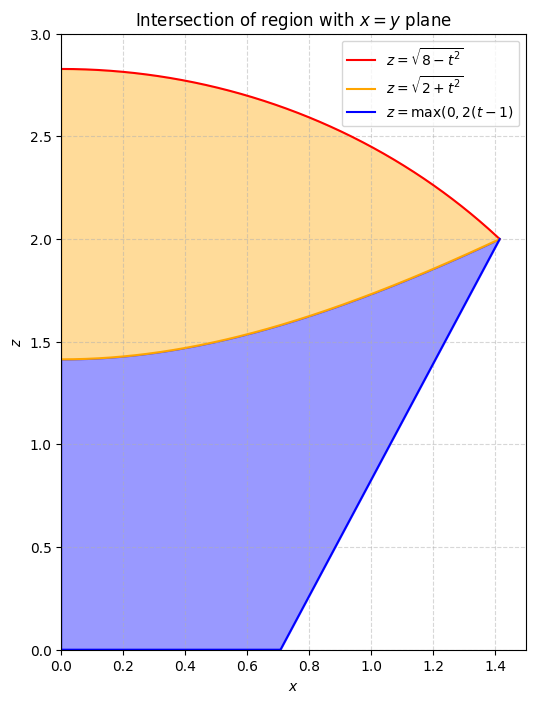

In [32]:
from moments.bloch import compute_bipartite_region_ent, compute_bipartite_region_lower, compute_bipartite_region_upper

x = np.linspace(0, 2 / np.sqrt(2), 1000)

z_upper = compute_bipartite_region_upper(dn, x, x)
z_ent = compute_bipartite_region_ent(dn, x, x)
z_lower = compute_bipartite_region_lower([dn, dn], x, x)

fig, ax = plt.subplots(figsize=(6, 8))

ax.plot(x, z_upper, 'red', label=r"$z = \sqrt{8 - t^2}$")
ax.plot(x, z_ent, 'orange', label=r"$z = \sqrt{2 + t^2}$")
ax.plot(x, z_lower, 'blue', label=r"$z = \max(0, 2 (t - 1)$")

ax.fill_between(x, z_upper, z_ent, alpha=0.4, color='orange')
ax.fill_between(x, z_ent, z_lower, alpha=0.4, color='blue')

ax.set(xlabel = r'$x$', ylabel = r'$z$', title = 'Intersection of region with $x=y$ plane',
       xlim = (0, 1.5), ylim = (0, 3))
ax.grid(True, alpha=0.5, linestyle="--")
ax.legend()
plt.show()

In [38]:
a, b = 0.5, 1.75
z = np.array([0, 0, 1, 0, 0, 0, 0, 0])
zz = np.kron(z, z)
r = {(1,): a * z, (2,): a * z, (1, 2): zz}

rho = compute_dm_from_bloch(tensor_basis, subset_index_map, r)
is_valid, _ = compute_is_valid_dm(rho)

N = compute_negativity(rho=rho)

print("Original state:\n")
print(rho)
print("\nIs a valid density matrix?", is_valid)
print("Negativity:", N)

Original state:

[[0.11111111+0.j 0.        +0.j 0.        +0.j 0.        +0.j
  0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
  0.        +0.j]
 [0.        +0.j 0.11111111+0.j 0.06804138+0.j 0.        +0.j
  0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
  0.        +0.j]
 [0.        +0.j 0.06804138+0.j 0.11111111+0.j 0.        +0.j
  0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
  0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.11111111+0.j
  0.        +0.j 0.        +0.j 0.06804138+0.j 0.        +0.j
  0.        +0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
  0.11111111+0.j 0.06804138+0.j 0.        +0.j 0.06804138+0.j
  0.16666667+0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.        +0.j
  0.06804138+0.j 0.11111111+0.j 0.        +0.j 0.16666667+0.j
  0.06804138+0.j]
 [0.        +0.j 0.        +0.j 0.        +0.j 0.06804138+0.j
  0.        +0.j 0.        +0.j 0.11111111+0.j 0.        +0.j
  0.   